In [1]:
import pandas as pd
df=pd.read_csv("sentiment_dataset.csv")
df.head()

,id,text,label,sentiment
0,0,"Cooking microwave pizzas, yummy",2,positive
1,1,Any plans of allowing sub tasks to show up in ...,1,neutral
2,2,"I love the humor, I just reworded it. Like sa...",2,positive
3,3,naw idk what ur talkin about,1,neutral
4,4,That sucks to hear. I hate days like that,0,negative


In [2]:
#%pip install nltk

In [3]:
import nltk
print(nltk.__version__)


3.9.2


In [4]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sent_df=pd.DataFrame()
def sentiment_intensity(data,column):
    sia=SentimentIntensityAnalyzer()
    Score=data[column].apply(lambda x:sia.polarity_scores(x))
    sent_df["Context"]=data[column]
    sent_df["Compound Score"]=data[column].apply(lambda x:sia.polarity_scores(x)['compound'])
    sent_df["Sentiment"]=sent_df["Compound Score"].apply(lambda x: "Positive" if x>=0.5 else "Negative" if x<0 else "Neutral")
    return Score,sent_df

In [5]:
Score,sent_df=sentiment_intensity(df,"text")

In [6]:
sent_df

,Context,Compound Score,Sentiment
0,"Cooking microwave pizzas, yummy",0.5267,Positive
1,Any plans of allowing sub tasks to show up in ...,0.0000,Neutral
2,"I love the humor, I just reworded it. Like sa...",0.9081,Positive
3,naw idk what ur talkin about,-0.1027,Negative
4,That sucks to hear. I hate days like that,-0.5719,Negative
...,...,...,...
31227,Grrrr....I got the wrong size coat for the sheep,-0.4767,Negative
31228,4 cases of swine flu!,-0.4389,Negative
31229,excellent,0.5719,Positive
31230,is sitting thru the boring bits in Titanic wai...,0.1531,Neutral


In [7]:
#%pip install spacy

In [8]:
#!pip install -U pip setuptools wheel
#!pip install -U spacy


In [23]:
x=sent_df["Context"]
y=sent_df["Sentiment"]

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [11]:
#!conda activate aiml
#!conda install pytorch torchvision torchaudio cpuonly -c pytorch


In [12]:
#!python -m spacy download en_core_web_sm


In [25]:
import spacy
lemma=spacy.load("en_core_web_sm")
def lemmatizer(text):
    doc=lemma(text)
    return [token.lemma_ for token in doc if not token.is_stop]

In [26]:
lemma(sent_df["Context"][0])

Cooking microwave pizzas, yummy

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vector=TfidfVectorizer(stop_words='english')
xtrain_vector=tfidf_vector.fit_transform(x_train)
xtest_vector=tfidf_vector.transform(x_test)

In [28]:
xtrain_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 194390 stored elements and shape (23424, 24089)>

In [29]:
from sklearn.decomposition import NMF
model_nmf=NMF(n_components=5,random_state=42)
model_nmf.fit(xtrain_vector)

,n_components,5
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,200
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


In [30]:
model_nmf.get_feature_names_out()

array(['nmf0', 'nmf1', 'nmf2', 'nmf3', 'nmf4'], dtype=object)

In [31]:
model_nmf.components_

array([[6.18576146e-03, 4.12692444e-04, 9.46140142e-04, ...,
        2.00957090e-03, 0.00000000e+00, 0.00000000e+00],
       [3.88528394e-04, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [8.56292313e-04, 9.71895994e-04, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [8.04077563e-03, 7.31707839e-03, 2.14144184e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.20613868e-03, 0.00000000e+00, 5.16132827e-04, ...,
        0.00000000e+00, 5.86055765e-81, 5.86055765e-81]], shape=(5, 24089))

In [35]:
for i,j in enumerate(model_nmf.components_):
    result=([tfidf_vector.get_feature_names_out()[n] for n in j.argsort()[-5:]])
    print(f"Topic {i+1}")
    print(result)

Topic 1
['love', 'tasks', 'use', 'great', 'app']
Topic 2
['mom', 'mothers', 'mother', 'happy', 'day']
Topic 3
['hope', 'luck', 'night', 'morning', 'good']
Topic 4
['got', 'don', 'know', 'like', 'just']
Topic 5
['today', 'tomorrow', 'time', 'doesn', 'work']


In [39]:
tfidf_vector.get_feature_names_out()

array(['00', '000', '00am', ..., '滴答清单', '非常喜欢', '非常棒'],
      shape=(24089,), dtype=object)

In [33]:
from sklearn.decomposition import LatentDirichletAllocation as LDA
lda=LDA(n_components=5,random_state=42)
lda.fit(xtrain_vector)


,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [41]:
for i,j in enumerate(lda.components_):
    result=([tfidf_vector.get_feature_names_out()[k] for k in j.argsort()[-5:]])
    print(f"Topic {i+1}")
    print(result)

Topic 1
['just', 'lol', 'oh', 'night', 'going']
Topic 2
['home', 'http', 'just', 'work', 'day']
Topic 3
['bad', 'http', 'just', 'miss', 'thanks']
Topic 4
['know', 'lol', 'just', 'good', 'haha']
Topic 5
['use', 'great', 'day', 'good', 'app']


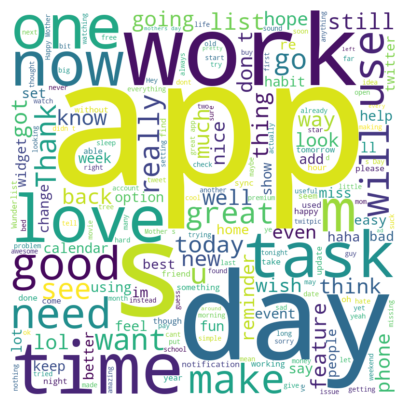

In [47]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text="".join(i for i in df['text'].astype(str))
cloud=WordCloud(width=800,height=800,background_color='white',colormap='viridis').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(cloud, interpolation='bilinear')
plt.axis("off")  
plt.show()

In [46]:
text

'Cooking microwave pizzas, yummyAny plans of allowing sub tasks to show up in the widget? I love the humor, I just reworded it. Like saying \'group therapy\' instead`a \'gang banging\'. Keeps my moms off my back.   Hahaha naw idk what ur talkin about That sucks to hear. I hate days like that Umm yeah. That`s probably a pretty good note to self because eeeeeewwwwwwww. whatever do you mean? That would panic me a little!  Maybe you can read on an orbitron at the gym like I do...when all else fails?!?Is sad when people`s phones are dead  sad face.In cafe management, the end of the month is nothing but numbers. My arty little head hurts from finding discrepenciesBasically I`ve listened to Miley Cyrus for fourteen hours now, and I love it. what did you think of the finale?  I thought it was kind of a cheap way out I think that boat sailed my friend... The few CCO`s that had them, had them months ago....  I wish you luck though...Gave my mommy her Mother`s Day present. Tickets to Aerosmith (h